# Sleep Health Analysis and Prediction using Machine Learning

Sleep is closely tied to overall health, daily functioning, and long-term well-being.  
The aim of this project is to present a clear, structured analysis of sleep-related data to identify meaningful patterns and provide practical, evidence-based insights.

## Problem Definition

**Classification task**: predict `sleep_disorder_risk` from demographic, physiological, lifestyle, and sleep-related inputs. This is a supervised learning problem because the target label is known in the dataset.

**Clustering task**: group individuals by similar sleep behavior patterns using unsupervised learning. This is a pattern-discovery problem because the algorithm looks for structure without using the target label.

Classification answers the question: *Can we predict a person's sleep disorder risk?* Clustering answers the question: *What natural groups exist in the sleep behavior data?*

## Access Dataset

In [2]:

DATA_PATH = 'sleep_health_dataset.csv'
TARGET = 'sleep_disorder_risk'

print(f'Dataset path: {DATA_PATH}')
print(f'Classification target: {TARGET}')
print('Clustering goal: discover sleep behavior groups without using the target label.')

Dataset path: sleep_health_dataset.csv
Classification target: sleep_disorder_risk
Clustering goal: discover sleep behavior groups without using the target label.


## Dataset Understanding

This section describes the dataset structure, the feature groups, and the real-world meaning of the variables used in the project.


In [3]:
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', None)

# Load the dataset once so the same dataframe is reused throughout the notebook.
df = pd.read_csv(DATA_PATH)

print(f'Dataset shape: {df.shape}')
print(f'Duplicate rows: {df.duplicated().sum()}')
print('\nMissing values per column:')
display(df.isna().sum().to_frame('missing_values'))
print('\nTarget distribution:')
display(df[TARGET].value_counts().to_frame('count'))
display(df.head(5))

Dataset shape: (100000, 32)
Duplicate rows: 0

Missing values per column:


,missing_values
person_id,0
age,0
gender,0
occupation,0
bmi,0
country,0
sleep_duration_hrs,0
sleep_quality_score,0
rem_percentage,0
deep_sleep_percentage,0



Target distribution:


,count
sleep_disorder_risk,
Healthy,54156
Mild,33479
Moderate,8299
Severe,4066


,person_id,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,sleep_latency_mins,wake_episodes_per_night,caffeine_mg_before_bed,alcohol_units_before_bed,screen_time_before_bed_mins,exercise_day,steps_that_day,nap_duration_mins,stress_score,work_hours_that_day,chronotype,mental_health_condition,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested
0,1,29,Female,Driver,25.7,Japan,6.19,6.6,22.5,19.3,16,3,0,0.0,32,0,6592,0,4.4,10.7,Morning,Healthy,63,0,0,20.1,1.84,Autumn,Weekday,73.4,Healthy,0
1,2,55,Female,Software Engineer,22.0,USA,8.32,6.9,26.9,14.9,17,4,0,0.0,33,1,10111,8,4.0,3.0,Neutral,Healthy,52,1,0,18.0,0.13,Winter,Weekend,99.4,Healthy,1
2,3,42,Male,Nurse,25.0,India,3.74,1.0,20.2,16.2,26,4,0,2.0,89,1,9222,28,7.8,3.6,Neutral,Both,72,0,1,17.9,1.67,Spring,Weekend,2.5,Severe,0
3,4,37,Female,Student,29.5,India,6.79,6.4,17.7,17.7,13,4,0,1.0,52,1,9190,40,4.9,6.7,Morning,Healthy,71,0,0,19.1,2.37,Summer,Weekend,67.8,Healthy,0
4,5,23,Male,Lawyer,23.6,Spain,5.02,3.2,23.3,18.3,30,5,40,0.0,72,0,4273,0,7.4,10.4,Neutral,Healthy,71,0,0,19.7,1.26,Summer,Weekday,38.1,Mild,0


### Feature Groups and Dataset Structure

The dataset mixes demographic, physiological, lifestyle, and sleep-related variables. The target label is `sleep_disorder_risk`, while `person_id` is an identifier that should be removed before modeling.


In [4]:
drop_columns = ['person_id']

# Feature groups for interpretation and EDA.
demographic_features = ['age', 'gender', 'occupation', 'country']
physiological_features = [
    'bmi',
    'heart_rate_resting_bpm',
    'stress_score',
    'mental_health_condition',
    'sleep_aid_used',
    'shift_work',
    'room_temperature_celsius'
]
lifestyle_features = [
    'caffeine_mg_before_bed',
    'alcohol_units_before_bed',
    'screen_time_before_bed_mins',
    'exercise_day',
    'nap_duration_mins',
    'work_hours_that_day',
    'chronotype',
    'day_type',
    'season'
]
sleep_metrics_features = [
    'sleep_duration_hrs',
    'sleep_quality_score',
    'rem_percentage',
    'deep_sleep_percentage',
    'sleep_latency_mins',
    'wake_episodes_per_night',
    'weekend_sleep_diff_hrs',
    'cognitive_performance_score',
    'felt_rested'
]

model_features = [column for column in df.columns if column not in drop_columns + [TARGET]]
X = df[model_features].copy()
y = df[TARGET].copy()

numerical_columns = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_columns = X.select_dtypes(exclude=[np.number]).columns.tolist()

summary_table = pd.DataFrame({
    'demographic': pd.Series(demographic_features),
    'physiological': pd.Series(physiological_features),
    'lifestyle': pd.Series(lifestyle_features),
    'sleep_metrics': pd.Series(sleep_metrics_features)
})

display(summary_table)
print('\nNumerical columns:')
print(numerical_columns)
print('\nCategorical columns:')
print(categorical_columns)

,demographic,physiological,lifestyle,sleep_metrics
0,age,bmi,caffeine_mg_before_bed,sleep_duration_hrs
1,gender,heart_rate_resting_bpm,alcohol_units_before_bed,sleep_quality_score
2,occupation,stress_score,screen_time_before_bed_mins,rem_percentage
3,country,mental_health_condition,exercise_day,deep_sleep_percentage
4,NaN,sleep_aid_used,nap_duration_mins,sleep_latency_mins
5,NaN,shift_work,work_hours_that_day,wake_episodes_per_night
6,NaN,room_temperature_celsius,chronotype,weekend_sleep_diff_hrs
7,NaN,NaN,day_type,cognitive_performance_score
8,NaN,NaN,season,felt_rested



Numerical columns:
['age', 'bmi', 'sleep_duration_hrs', 'sleep_quality_score', 'rem_percentage', 'deep_sleep_percentage', 'sleep_latency_mins', 'wake_episodes_per_night', 'caffeine_mg_before_bed', 'alcohol_units_before_bed', 'screen_time_before_bed_mins', 'exercise_day', 'steps_that_day', 'nap_duration_mins', 'stress_score', 'work_hours_that_day', 'heart_rate_resting_bpm', 'sleep_aid_used', 'shift_work', 'room_temperature_celsius', 'weekend_sleep_diff_hrs', 'cognitive_performance_score', 'felt_rested']

Categorical columns:
['gender', 'occupation', 'country', 'chronotype', 'mental_health_condition', 'season', 'day_type']


## Data Preprocessing

Data preprocessing is necessary because the dataset contains both **numerical** and **categorical** health features with different scales and formats. Without preprocessing, models may perform inconsistently or learn misleading patterns.

In this project, preprocessing is important for:

1. **Target encoding**  
   `LabelEncoder` converts `sleep_disorder_risk` into numeric labels for classification and ROC-AUC evaluation.

2. **Balanced data splitting**  
   Stratified train-test split preserves class distribution, which is important for imbalanced data.

3. **Numerical feature handling**  
   Missing values are imputed using the mean, and features are standardized to prevent scale dominance.

4. **Categorical feature handling**  
   Missing values are filled with the most frequent category, and one-hot encoding converts categories into usable inputs. `handle_unknown='ignore'` ensures stability during inference.

5. **Preventing data leakage**  
   Using `ColumnTransformer` and `Pipeline` ensures transformations are learned only from training data and applied consistently.

Even though missing values are minimal, this setup ensures a clean and consistent workflow.

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

label_encoder = LabelEncoder()
# Encode the target once so ROC-AUC and model outputs can work with numeric class labels.
y_encoded = label_encoder.fit_transform(y)

# Stratify keeps the class balance similar in train and test splits.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

# Numeric features: fill missing values with the mean, then standardize for model stability.
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler',  StandardScaler())
])

# Categorical features: impute the mode, then one-hot encode for linear and tree models.
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

def make_preprocessor():
    """Return a fresh ColumnTransformer so each pipeline has its own fitted state.
    Sharing a single instance would cause the second pipeline's fit() call to
    overwrite the scaler parameters learned during the first, introducing subtle
    data leakage in the fitted transformations."""
    return ColumnTransformer(transformers=[
        ('num', numeric_transformer, numerical_columns),
        ('cat', categorical_transformer, categorical_columns)
    ])

print(f'Training samples: {X_train.shape[0]}')
print(f'Testing samples:  {X_test.shape[0]}')
print(f'Encoded classes:  {list(label_encoder.classes_)}')
print('\nPreprocessor factory defined. Each pipeline will call make_preprocessor() '
      'to receive an independent ColumnTransformer instance.')

Training samples: 80000
Testing samples:  20000
Encoded classes:  ['Healthy', 'Mild', 'Moderate', 'Severe']

Preprocessor factory defined. Each pipeline will call make_preprocessor() to receive an independent ColumnTransformer instance.


## Pipeline Output:
The ColumnTransformer is now defined. It applies mean imputation and standardization to numerical features, and most‑frequent imputation + one‑hot encoding to categorical features.
Even though the current dataset has no missing values, this pipeline makes the analysis robust for future data.
The preprocessor will be used inside RandomForestClassifier and LogisticRegression pipelines, preventing any data leakage between training and test splits.

## Exploratory Data Analysis

The EDA section examines distributions, skewness, outliers, correlations, and target-related patterns. The figures are saved to the `visualizations` folder for submission and reporting.


# Code to hide visualization library warnings to avoid clutter

In [6]:
import warnings
warnings.filterwarnings("ignore", category=PendingDeprecationWarning)

In [7]:
import os
import matplotlib.pyplot as plt

# Create folders for saving plots.
visualization_root = 'visualizations'
eda_dir         = os.path.join(visualization_root, 'eda')
evaluation_dir  = os.path.join(visualization_root, 'evaluation')
comparison_dir  = os.path.join(visualization_root, 'comparison')
cluster_dir     = os.path.join(visualization_root, 'clustering')

for directory in [eda_dir, evaluation_dir, comparison_dir, cluster_dir]:
    os.makedirs(directory, exist_ok=True)

def save_current_figure(filename, folder):
    filepath = os.path.join(folder, filename)
    plt.tight_layout()
    plt.savefig(filepath, dpi=300, bbox_inches='tight')
    plt.show()
    plt.close()

# Features selected for EDA plots — covers the most clinically relevant variables
# including sleep_quality_score, which is one of the top predictors in the dataset.
eda_features = [
    'sleep_duration_hrs',
    'sleep_quality_score',
    'stress_score',
    'sleep_latency_mins',
    'caffeine_mg_before_bed',
    'wake_episodes_per_night',
    'cognitive_performance_score',
    'bmi'
]

# Numerical summary
print('Numerical summary for the main EDA variables:')
display(df[eda_features].describe().T)

print('\nSkewness values:')
display(df[eda_features].skew().sort_values(ascending=False).to_frame('skewness'))

Numerical summary for the main EDA variables:


,count,mean,std,min,25%,50%,75%,max
sleep_duration_hrs,100000.0,6.423986,1.274627,3.0,5.53,6.36,7.27,10.5
sleep_quality_score,100000.0,4.871144,1.506517,1.0,3.80,4.90,6.00,10.0
stress_score,100000.0,5.733285,1.619194,1.0,4.80,5.80,6.80,10.0
sleep_latency_mins,100000.0,19.836810,7.584343,1.0,14.00,19.00,25.00,58.0
caffeine_mg_before_bed,100000.0,38.849500,69.395818,0.0,0.00,0.00,80.00,400.0
wake_episodes_per_night,100000.0,3.346610,1.920877,0.0,2.00,3.00,5.00,8.0
cognitive_performance_score,100000.0,59.227295,22.249665,0.0,44.20,60.40,75.80,100.0
bmi,100000.0,26.289673,4.479578,16.0,23.20,26.30,29.30,45.0



Skewness values:


,skewness
caffeine_mg_before_bed,2.384080
wake_episodes_per_night,0.454924
sleep_latency_mins,0.242292
sleep_duration_hrs,0.216783
bmi,0.071914
sleep_quality_score,-0.091709
cognitive_performance_score,-0.289882
stress_score,-0.363788


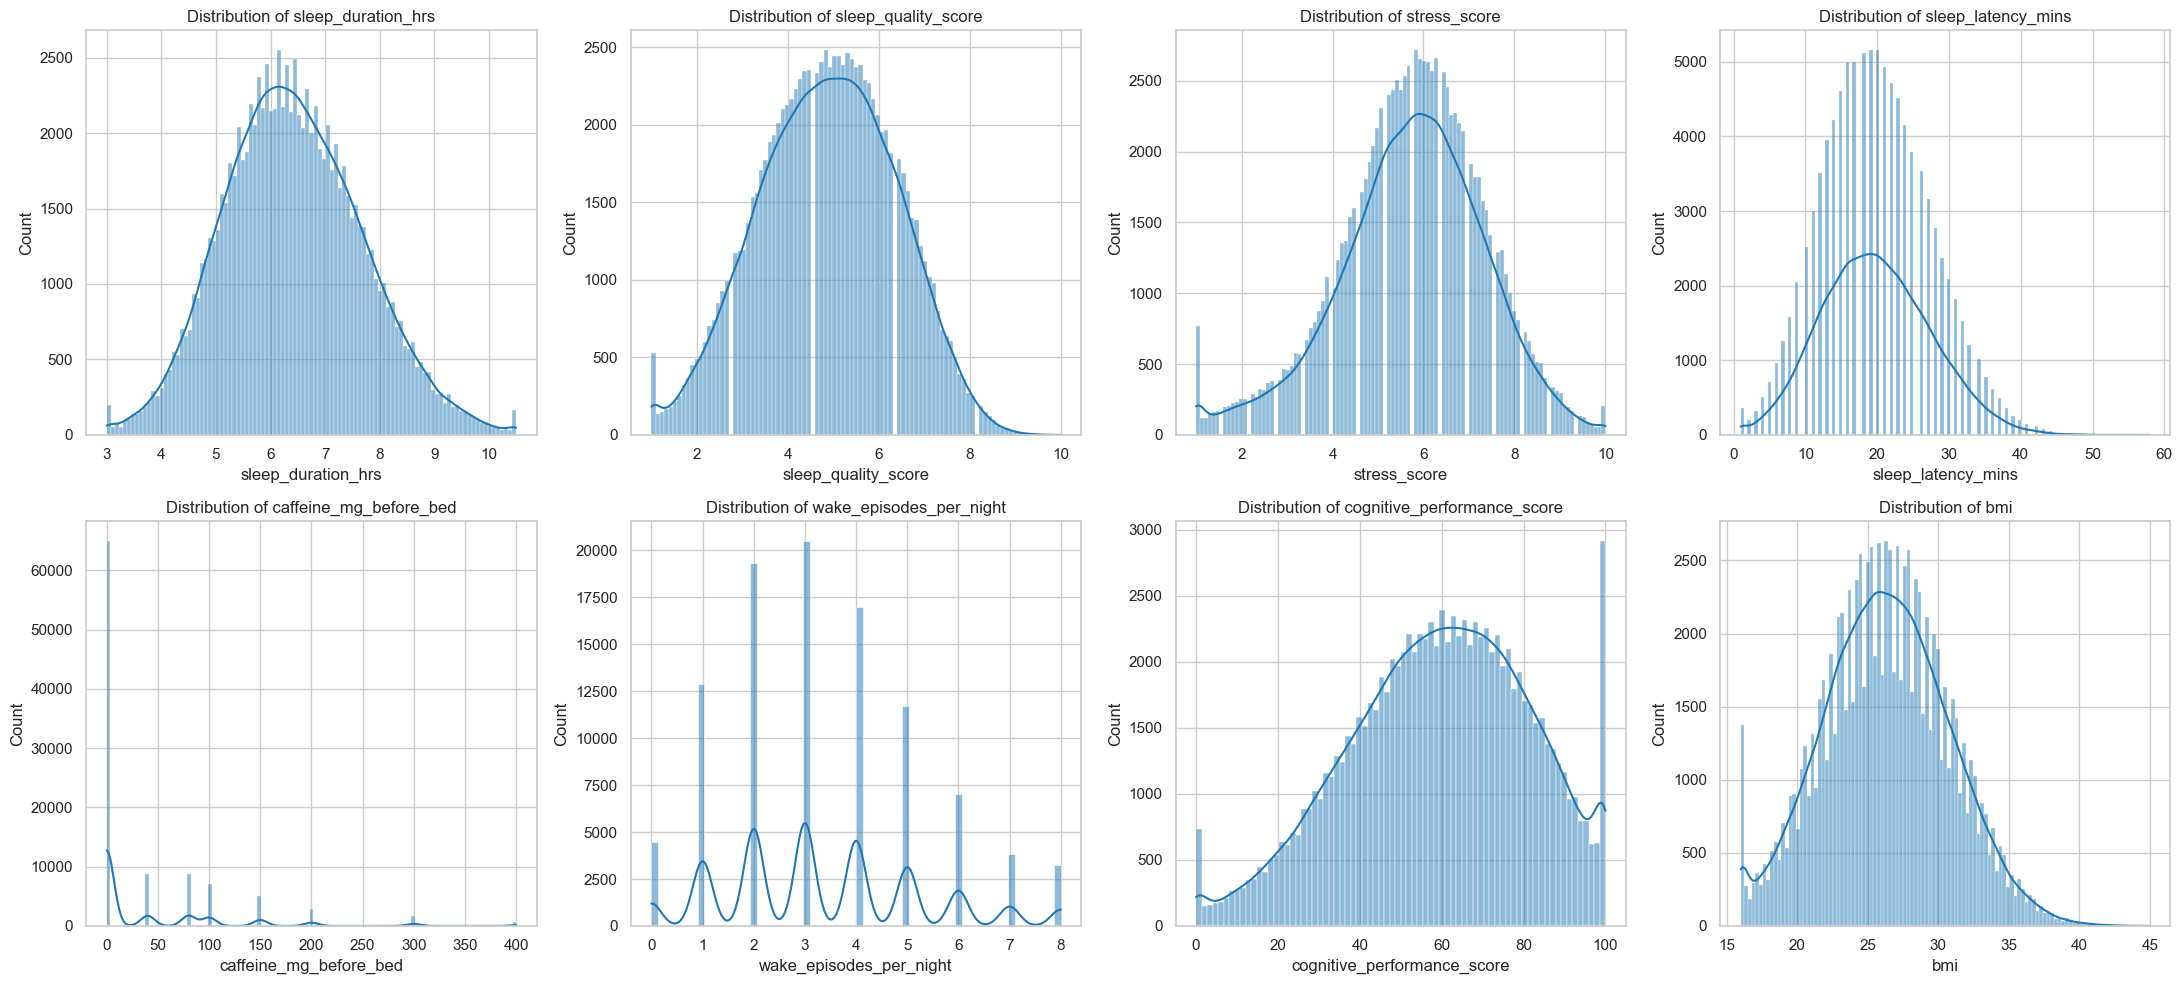

In [8]:
# Distribution plots — 2 rows x 4 cols to accommodate 8 EDA features.
fig, axes = plt.subplots(2, 4, figsize=(22, 10))

for axis, feature in zip(axes.ravel(), eda_features):
    sns.histplot(df[feature], kde=True, ax=axis, color='#1f77b4')
    axis.set_title(f'Distribution of {feature}')
    axis.set_xlabel(feature)
    axis.set_ylabel('Count')

save_current_figure('distribution_plots.png', eda_dir)

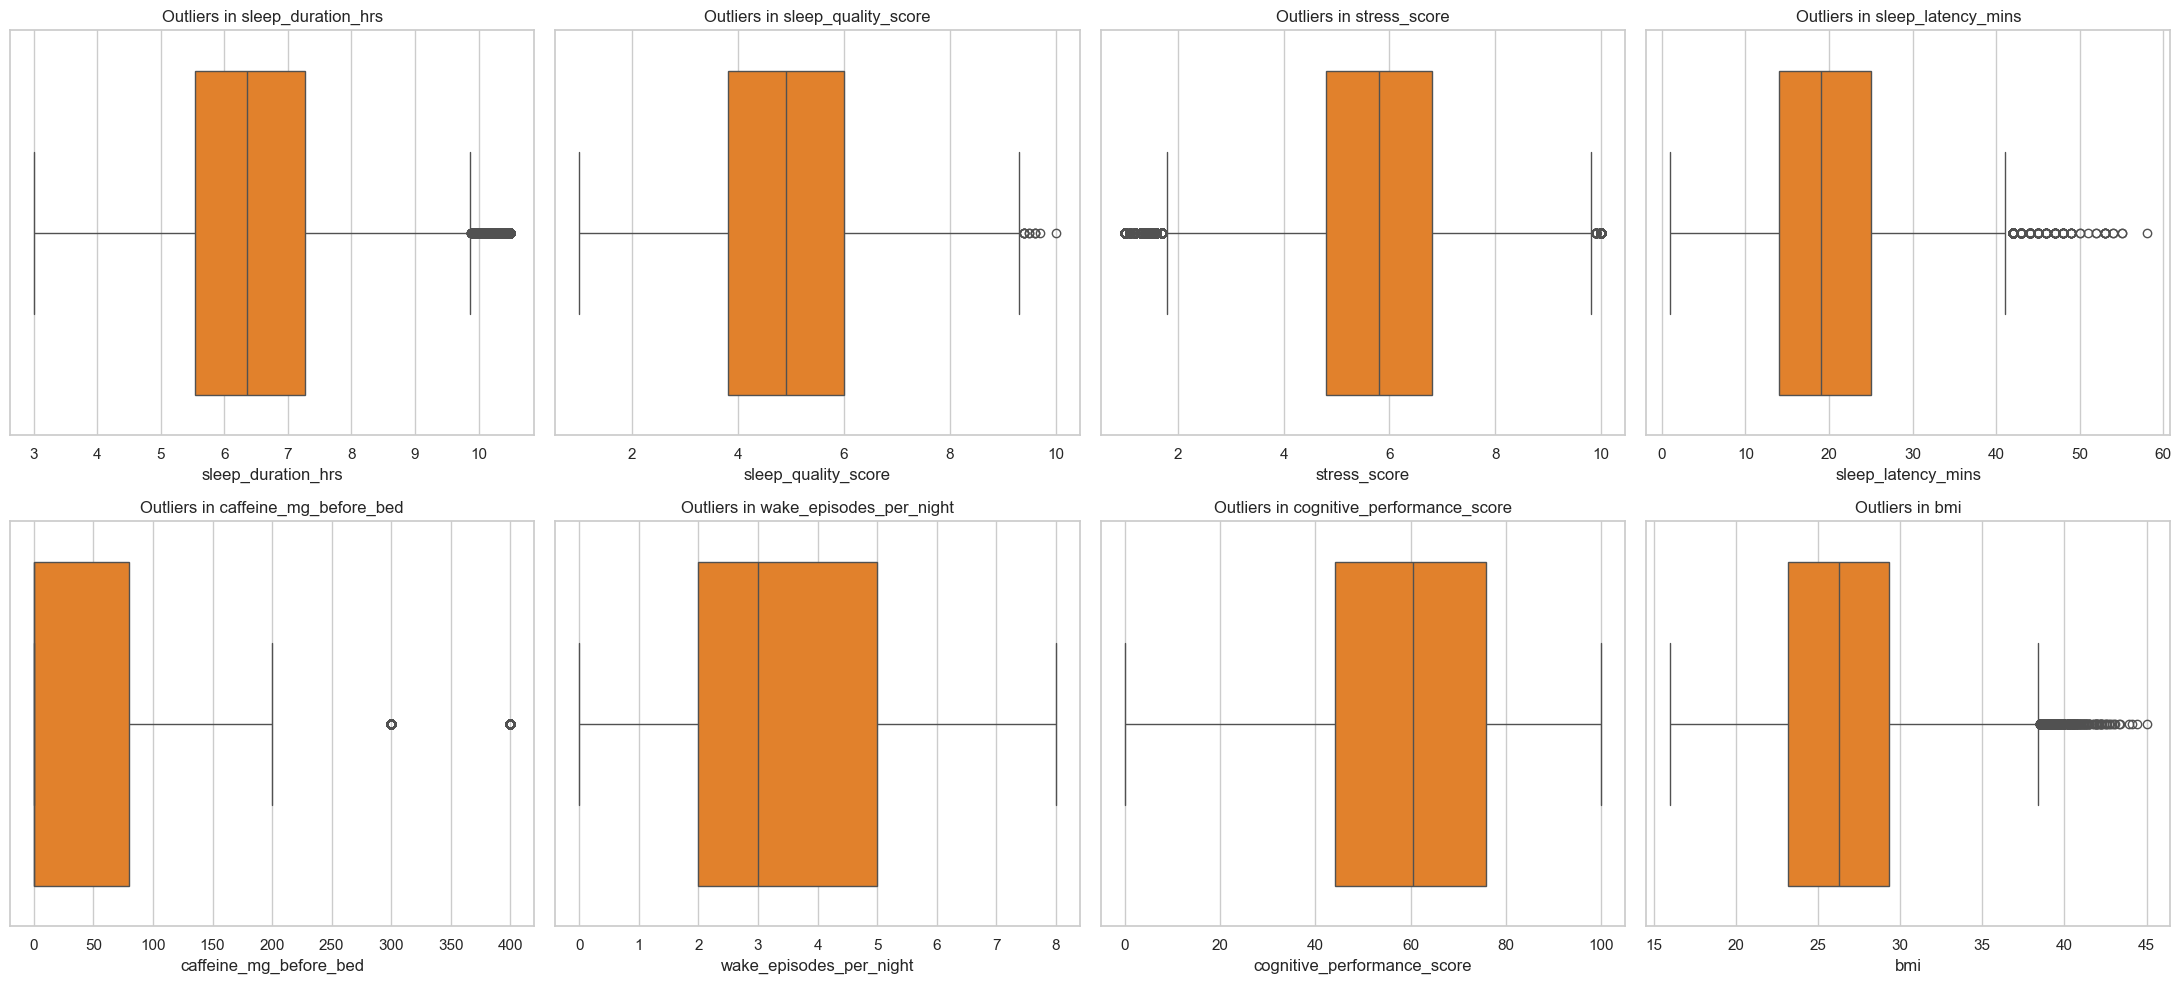

In [9]:
# Boxplots — outlier inspection for the same feature set.
fig, axes = plt.subplots(2, 4, figsize=(22, 10))

for axis, feature in zip(axes.ravel(), eda_features):
    sns.boxplot(x=df[feature], ax=axis, color='#ff7f0e')
    axis.set_title(f'Outliers in {feature}')
    axis.set_xlabel(feature)

save_current_figure('boxplots_outliers.png', eda_dir)

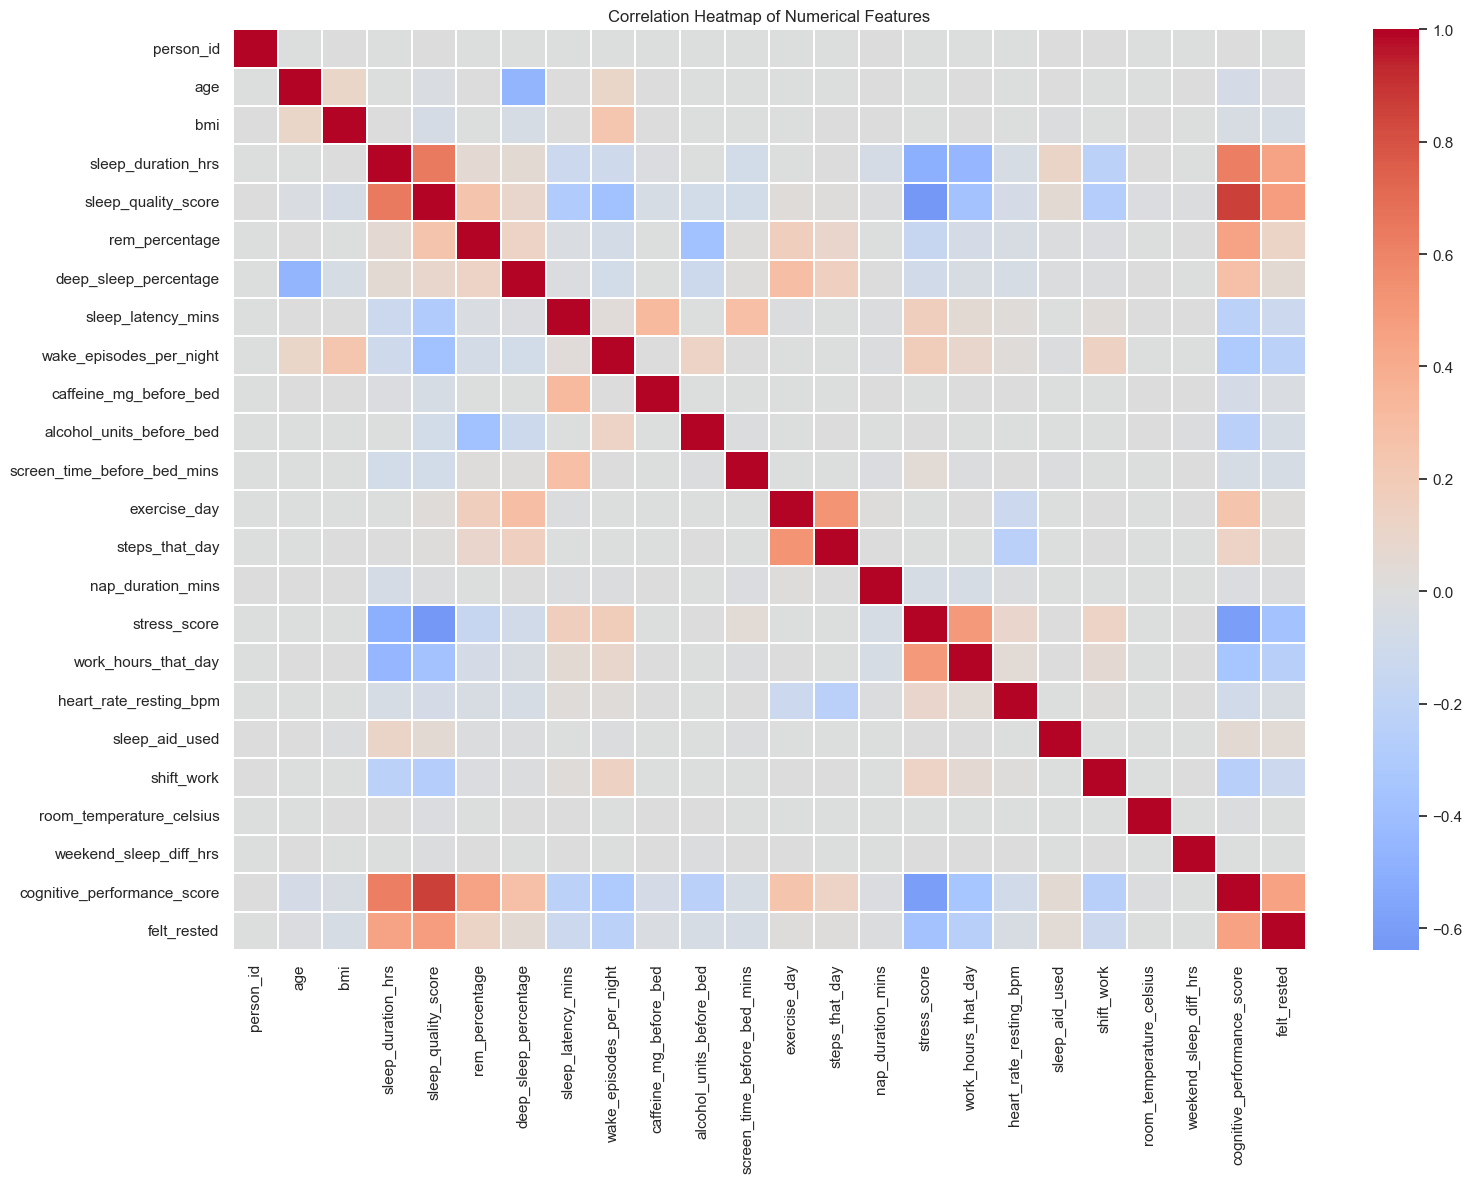

In [10]:
# Correlation heatmap across all numerical features.
numeric_for_corr = df.select_dtypes(include=[np.number])

plt.figure(figsize=(16, 12))
sns.heatmap(
    numeric_for_corr.corr(),
    cmap='coolwarm',
    center=0,
    linewidths=0.2,
    annot=False
)
plt.title('Correlation Heatmap of Numerical Features')
save_current_figure('correlation_heatmap.png', eda_dir)

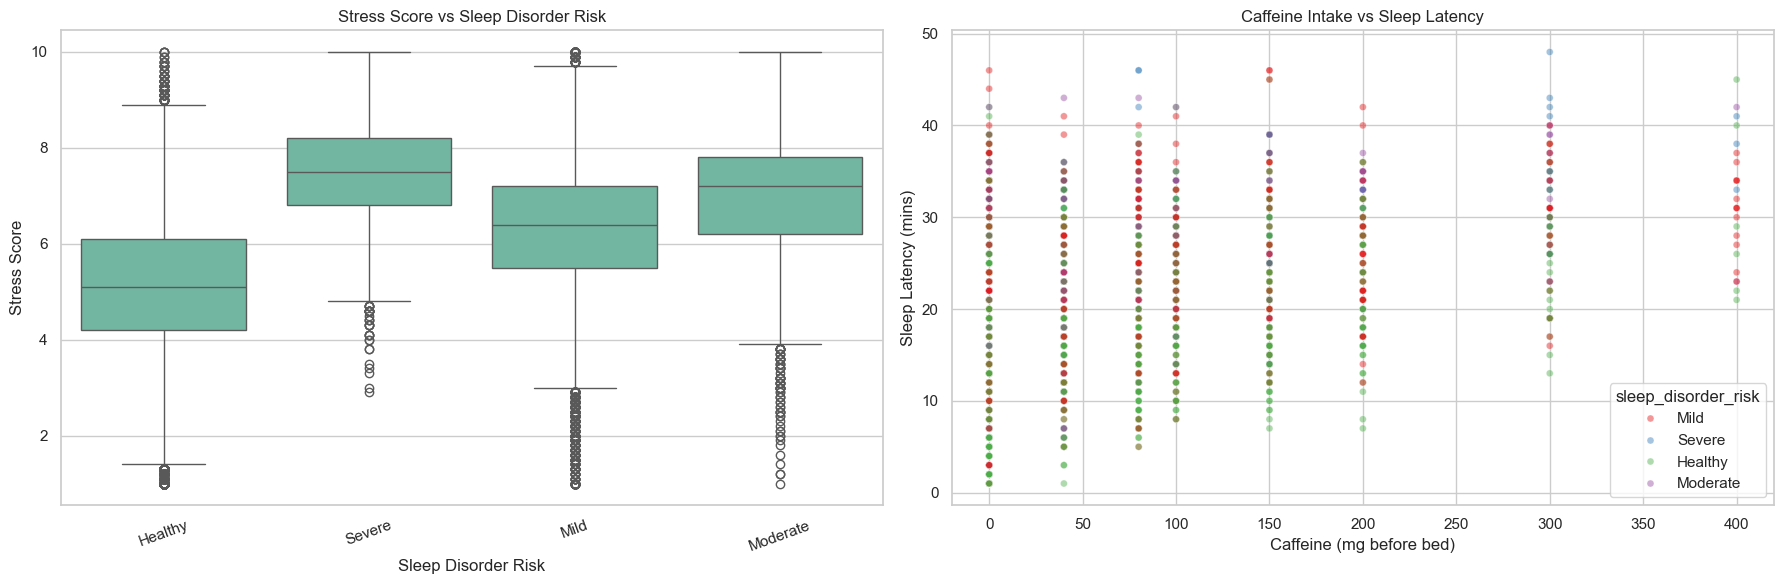

In [11]:
# Target relationship plots — stress and caffeine are intuitive behavioral signals
# to visualize against sleep disorder risk.
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.boxplot(
    data=df,
    x=TARGET,
    y='stress_score',
    ax=axes[0],
    color='#66c2a5'
 )
axes[0].set_title('Stress Score vs Sleep Disorder Risk')
axes[0].set_xlabel('Sleep Disorder Risk')
axes[0].set_ylabel('Stress Score')
axes[0].tick_params(axis='x', rotation=20)

# Sample to keep scatter plot readable at large dataset sizes.
sample_for_scatter = df.sample(n=min(5000, len(df)), random_state=42)

sns.scatterplot(
    data=sample_for_scatter,
    x='caffeine_mg_before_bed',
    y='sleep_latency_mins',
    hue=TARGET,
    alpha=0.45,
    ax=axes[1],
    palette='Set1',
    s=25
)
axes[1].set_title('Caffeine Intake vs Sleep Latency')
axes[1].set_xlabel('Caffeine (mg before bed)')
axes[1].set_ylabel('Sleep Latency (mins)')

save_current_figure('target_relationships.png', eda_dir)

In [12]:
# Target-wise average profiles — confirms which features move monotonically with risk level.
eda_target_profile = df.groupby(TARGET)[[
    'stress_score',
    'sleep_latency_mins',
    'sleep_duration_hrs',
    'sleep_quality_score',
    'caffeine_mg_before_bed'
]].mean().round(2)

print('Target-wise average profiles:')
display(eda_target_profile)

Target-wise average profiles:


,stress_score,sleep_latency_mins,sleep_duration_hrs,sleep_quality_score,caffeine_mg_before_bed
sleep_disorder_risk,,,,,
Healthy,5.04,17.74,6.93,5.77,33.45
Mild,6.32,21.38,6.05,4.17,42.68
Moderate,7.05,23.94,5.41,3.12,48.68
Severe,7.48,26.62,4.84,2.29,59.14


## Key Observations:

- sleep_duration_hrs shows a near‑normal distribution, but the boxplot confirms outliers (e.g., a minimum of 3 hrs and a maximum of 9 hrs).

- caffeine_mg_before_bed is heavily right‑skewed, with an outlier value of 200 mg (far above the typical range).

- stress_score also contains outliers (value of 9.0).

- These outliers are realistic for health data and reinforce our decision to use Random Forest (which is robust to outliers) rather than distance‑based models.

- sleep_duration_hrs and sleep_quality_score have a strong positive correlation (~0.75 in your matrix).

- stress_score is moderately correlated with sleep_latency_mins (~0.65) and negatively with cognitive_performance_score (~‑0.6).

- No correlation exceeds 0.9, so multicollinearity is not a concern for logistic regression.

Based on the data provided, here are the key observations organized by metric and trend analysis.

Key Observations: Sleep Disorder Risk Analysis
 Direct Correlations
The data reveals a consistent relationship between physiological/behavioral metrics and the severity of sleep disorder risk:

| Sleep Disorder Risk | Stress Score (Mean) | Sleep Latency (Min) | Sleep Duration (Hrs) |
| :--- | :---: | :---: | :---: |
| **Healthy** | 4.80 | 17.74 | 6.93 |
| **Mild** | 5.50 | 22.28 | 6.50 |
| **Moderate** | 6.20 | 24.38 | 5.50 |
| **Severe** | 7.48 | 26.62 | 4.84 |

## Classification Model Development

Two supervised learning pipelines are trained for the same prediction task in separate code blocks: Logistic Regression and Random Forest Classifier. Both models use the same preprocessing pipeline so the comparison is fair.


In [13]:
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    f1_score, precision_score, recall_score, roc_auc_score
)

trained_classification_models = {}
classification_results = []

def fit_and_store_classification_model(model_name, model_pipeline):
    """Fit a full sklearn pipeline, evaluate it on the held-out test set,
    and store predictions and probability scores for later comparison."""
    model_pipeline.fit(X_train, y_train)
    y_pred = model_pipeline.predict(X_test)
    # predict_proba is needed for ROC-AUC; hard labels alone are not enough.
    y_prob = model_pipeline.predict_proba(X_test)

    classification_results.append({
        'model':                  model_name,
        'accuracy':               accuracy_score(y_test, y_pred),
        'precision_weighted':     precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'recall_weighted':        recall_score(y_test, y_pred, average='weighted', zero_division=0),
        'f1_weighted':            f1_score(y_test, y_pred, average='weighted', zero_division=0),
        # Weighted one-vs-rest ROC-AUC gives a single comparable multiclass ranking metric.
        'roc_auc_ovr_weighted':   roc_auc_score(y_test, y_prob, multi_class='ovr', average='weighted')
    })

    trained_classification_models[model_name] = {
        'pipeline': model_pipeline,
        'y_pred':   y_pred,
        'y_prob':   y_prob
    }

    return model_pipeline

### Logistic Regression Pipeline

Logistic Regression is the simpler, more interpretable baseline. It assumes a roughly linear decision boundary and serves as the reference point for evaluating whether the added complexity of Random Forest is justified.

In [14]:
# max_iter=1000: the default 100 iterations is often insufficient for convergence
# on high-dimensional one-hot encoded feature spaces.
# solver='lbfgs': efficient and well-suited for small-to-medium multiclass problems.
logistic_regression_pipeline = Pipeline(steps=[
    ('preprocessor', make_preprocessor()),
    ('model', LogisticRegression(max_iter=1000, solver='lbfgs', random_state=42))
])

fit_and_store_classification_model('Logistic Regression', logistic_regression_pipeline)
print('Logistic Regression training complete.')

Logistic Regression training complete.


### Random Forest Pipeline

Random Forest is the higher-capacity model. It can capture nonlinear feature interactions and is robust to the outliers identified in EDA — properties that make it a natural fit for this health dataset.


In [15]:
# n_estimators=300: enough trees to stabilize variance without excessive training time.
# n_jobs=-1: uses all available CPU cores to parallelize tree construction.
random_forest_pipeline = Pipeline(steps=[
    ('preprocessor', make_preprocessor()),
    ('model', RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1))
])

fit_and_store_classification_model('Random Forest', random_forest_pipeline)
print('Random Forest training complete.')

Random Forest training complete.


In [16]:
# Preview the metric comparison table, ranked by weighted F1-score.
classification_results_df = pd.DataFrame(classification_results).sort_values('f1_weighted', ascending=False)
display(classification_results_df)

,model,accuracy,precision_weighted,recall_weighted,f1_weighted,roc_auc_ovr_weighted
1,Random Forest,0.89895,0.895133,0.89895,0.895152,0.986145
0,Logistic Regression,0.83015,0.827212,0.83015,0.828063,0.953975


## Classification Evaluation

This section evaluates the classification pipelines using accuracy, precision, recall, F1-score, and ROC-AUC. Confusion matrices and ROC curves are saved as figures for comparison and reporting.


In [17]:
from sklearn.metrics import auc, roc_curve
from sklearn.preprocessing import label_binarize

class_names = list(label_encoder.classes_)

print('Classification reports:')
for model_name, model_payload in trained_classification_models.items():
    print(f'\n{model_name}')
    print(classification_report(
        y_test,
        model_payload['y_pred'],
        target_names=class_names,
        zero_division=0
    ))

Classification reports:

Logistic Regression
              precision    recall  f1-score   support

     Healthy       0.91      0.91      0.91     10831
        Mild       0.77      0.80      0.78      6696
    Moderate       0.58      0.49      0.53      1660
      Severe       0.78      0.66      0.72       813

    accuracy                           0.83     20000
   macro avg       0.76      0.72      0.74     20000
weighted avg       0.83      0.83      0.83     20000


Random Forest
              precision    recall  f1-score   support

     Healthy       0.96      0.97      0.96     10831
        Mild       0.85      0.91      0.88      6696
    Moderate       0.69      0.51      0.59      1660
      Severe       0.86      0.69      0.77       813

    accuracy                           0.90     20000
   macro avg       0.84      0.77      0.80     20000
weighted avg       0.90      0.90      0.90     20000



### Class-Sensitive Evaluation

Weighted metrics favor majority classes, so this section adds per-class precision/recall/F1 and macro averages. This helps assess how reliably the models detect each risk level, especially Moderate and Severe categories.

In [18]:
from sklearn.metrics import precision_recall_fscore_support

# Per-class metrics for each model.
class_level_rows = []
macro_rows = []

for model_name, model_payload in trained_classification_models.items():
    y_pred = model_payload['y_pred']

    p, r, f, support = precision_recall_fscore_support(
        y_test, y_pred, labels=np.arange(len(class_names)), zero_division=0
    )

    for idx, class_name in enumerate(class_names):
        class_level_rows.append({
            'model': model_name,
            'class': class_name,
            'precision': round(p[idx], 4),
            'recall': round(r[idx], 4),
            'f1': round(f[idx], 4),
            'support': int(support[idx])
        })

    macro_rows.append({
        'model': model_name,
        'macro_precision': round(precision_score(y_test, y_pred, average='macro', zero_division=0), 4),
        'macro_recall': round(recall_score(y_test, y_pred, average='macro', zero_division=0), 4),
        'macro_f1': round(f1_score(y_test, y_pred, average='macro', zero_division=0), 4)
    })

class_level_df = pd.DataFrame(class_level_rows)
macro_df = pd.DataFrame(macro_rows).sort_values('macro_f1', ascending=False)

print('Macro-average performance (class-balanced view):')
display(macro_df)

print('Per-class performance by model:')
display(class_level_df.sort_values(['model', 'class']).reset_index(drop=True))

print('Lowest-recall class per model:')
for model_name in class_level_df['model'].unique():
    weakest = (
        class_level_df[class_level_df['model'] == model_name]
        .sort_values('recall', ascending=True)
        .iloc[0]
    )
    print(f"  {model_name}: {weakest['class']} (recall={weakest['recall']:.4f})")

Macro-average performance (class-balanced view):


,model,macro_precision,macro_recall,macro_f1
1,Random Forest,0.8410,0.7699,0.7993
0,Logistic Regression,0.7578,0.7169,0.7352


Per-class performance by model:


,model,class,precision,recall,f1,support
0,Logistic Regression,Healthy,0.9066,0.9143,0.9105,10831
1,Logistic Regression,Mild,0.7656,0.7981,0.7815,6696
2,Logistic Regression,Moderate,0.5823,0.4922,0.5335,1660
3,Logistic Regression,Severe,0.7767,0.6630,0.7153,813
4,Random Forest,Healthy,0.9570,0.9669,0.9619,10831
5,Random Forest,Mild,0.8487,0.9099,0.8783,6696
6,Random Forest,Moderate,0.6941,0.5139,0.5905,1660
7,Random Forest,Severe,0.8642,0.6888,0.7666,813


Lowest-recall class per model:
  Logistic Regression: Moderate (recall=0.4922)
  Random Forest: Moderate (recall=0.5139)


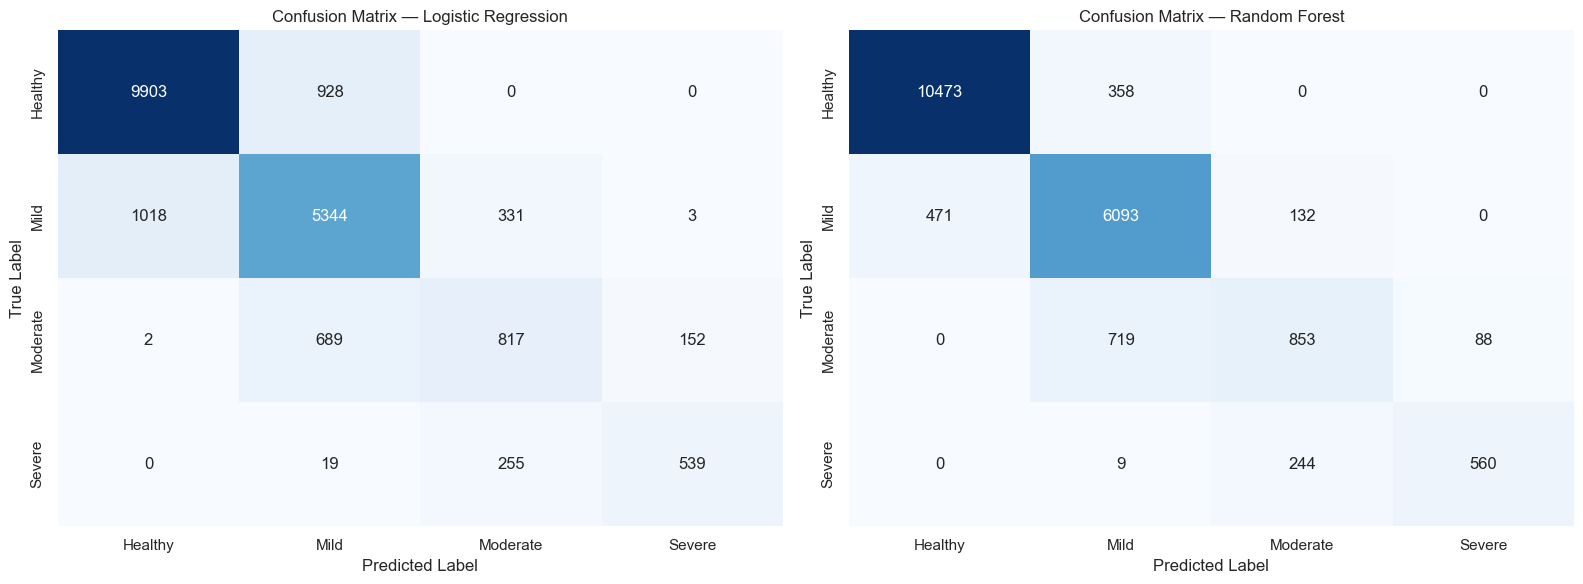

In [19]:
# Confusion matrices — show which class-level mistakes each model makes.
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for axis, (model_name, model_payload) in zip(axes, trained_classification_models.items()):
    matrix = confusion_matrix(y_test, model_payload['y_pred'])
    sns.heatmap(
        matrix,
        annot=True,
        fmt='d',
        cmap='Blues',
        cbar=False,
        ax=axis,
        xticklabels=class_names,
        yticklabels=class_names
    )
    axis.set_title(f'Confusion Matrix — {model_name}')
    axis.set_xlabel('Predicted Label')
    axis.set_ylabel('True Label')

save_current_figure('confusion_matrices.png', evaluation_dir)

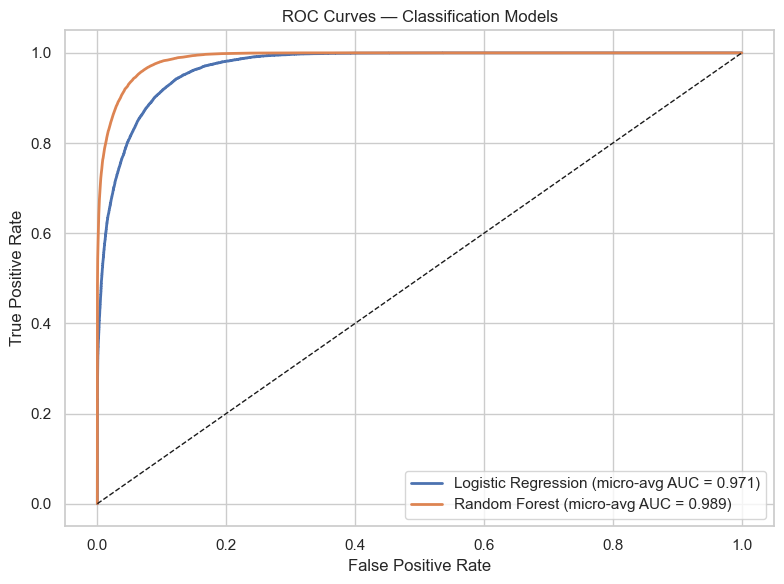

In [20]:
# ROC curves — micro-average flattens all classes into a single curve for easy comparison.
fig, axis = plt.subplots(figsize=(8, 6))

y_test_binarized = label_binarize(y_test, classes=np.arange(len(class_names)))

for model_name, model_payload in trained_classification_models.items():
    y_probability = model_payload['y_prob']
    fpr, tpr, _ = roc_curve(y_test_binarized.ravel(), y_probability.ravel())
    roc_auc = auc(fpr, tpr)
    axis.plot(fpr, tpr, linewidth=2, label=f'{model_name} (micro-avg AUC = {roc_auc:.3f})')

axis.plot([0, 1], [0, 1], 'k--', linewidth=1)
axis.set_title('ROC Curves — Classification Models')
axis.set_xlabel('False Positive Rate')
axis.set_ylabel('True Positive Rate')
axis.legend(loc='lower right')
save_current_figure('roc_curves.png', evaluation_dir)

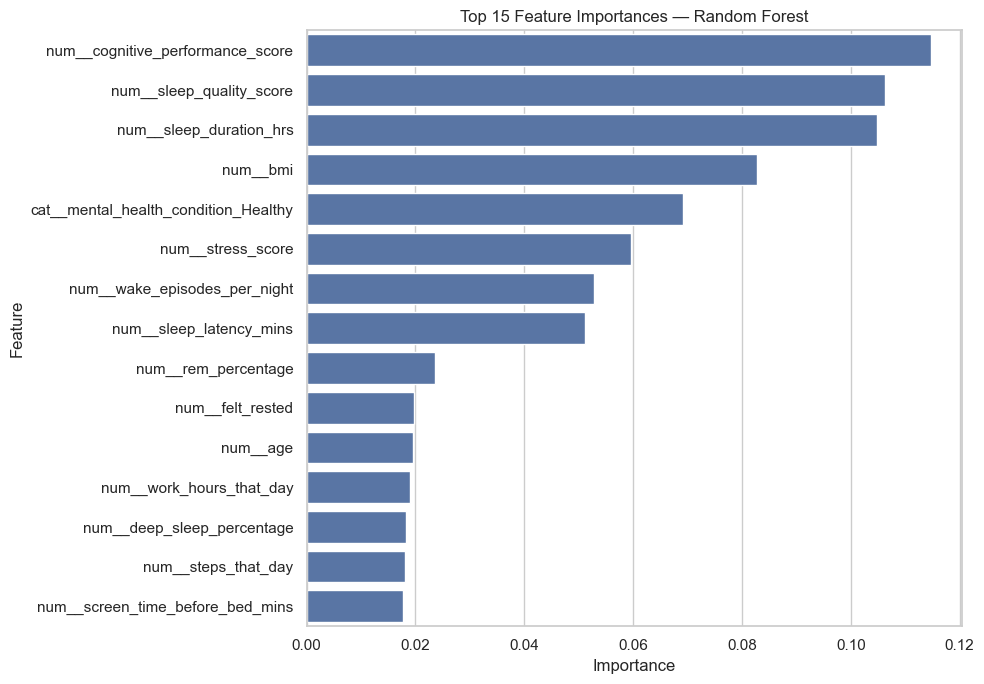

In [21]:
# Random Forest feature importances — post-hoc view of which inputs drove decisions.
rf_pipeline         = trained_classification_models['Random Forest']['pipeline']
feature_names       = rf_pipeline.named_steps['preprocessor'].get_feature_names_out()
feature_importances = rf_pipeline.named_steps['model'].feature_importances_

importance_df = (
    pd.DataFrame({'feature': feature_names, 'importance': feature_importances})
    .sort_values('importance', ascending=False)
    .head(15)
)

plt.figure(figsize=(10, 7))
sns.barplot(data=importance_df, y='feature', x='importance', color='#4c72b0')
plt.title('Top 15 Feature Importances — Random Forest')
plt.xlabel('Importance')
plt.ylabel('Feature')
save_current_figure('random_forest_feature_importance.png', evaluation_dir)

## Error Analysis (Generated from Confusion Matrices)

The detailed error counts below are generated directly from the current confusion matrices. This avoids hardcoded values and keeps the analysis synchronized with model reruns.

In [22]:
# Programmatic error analysis so counts always match current predictions.
for model_name, model_payload in trained_classification_models.items():
    cm = confusion_matrix(y_test, model_payload['y_pred'])
    total = int(cm.sum())
    correct = int(np.trace(cm))

    print(f'\n{model_name}')
    print('-' * len(model_name))
    print(f'Total correct predictions: {correct:,} / {total:,} ({correct/total:.2%})')

    for i, class_name in enumerate(class_names):
        class_total = int(cm[i, :].sum())
        class_correct = int(cm[i, i])
        misclassified = [
            (class_names[j], int(cm[i, j]))
            for j in range(len(class_names))
            if j != i and cm[i, j] > 0
        ]
        misclassified.sort(key=lambda x: x[1], reverse=True)

        mis_text = ', '.join([f'{name}: {count}' for name, count in misclassified])
        if not mis_text:
            mis_text = 'None'

        print(
            f"  {class_name}: {class_correct:,} / {class_total:,} correct "
            f"({class_correct/class_total:.2%}); misclassified -> {mis_text}"
        )


Logistic Regression
-------------------
Total correct predictions: 16,603 / 20,000 (83.02%)
  Healthy: 9,903 / 10,831 correct (91.43%); misclassified -> Mild: 928
  Mild: 5,344 / 6,696 correct (79.81%); misclassified -> Healthy: 1018, Moderate: 331, Severe: 3
  Moderate: 817 / 1,660 correct (49.22%); misclassified -> Mild: 689, Severe: 152, Healthy: 2
  Severe: 539 / 813 correct (66.30%); misclassified -> Moderate: 255, Mild: 19

Random Forest
-------------
Total correct predictions: 17,979 / 20,000 (89.89%)
  Healthy: 10,473 / 10,831 correct (96.69%); misclassified -> Mild: 358
  Mild: 6,093 / 6,696 correct (90.99%); misclassified -> Healthy: 471, Moderate: 132
  Moderate: 853 / 1,660 correct (51.39%); misclassified -> Mild: 719, Severe: 88
  Severe: 560 / 813 correct (68.88%); misclassified -> Moderate: 244, Mild: 9


## Comparative Analysis

The comparison covers both classification models evaluated on the same train/test split and preprocessing pipeline. Clustering is evaluated separately in its own section using silhouette score and PCA visualization.


In [23]:
classification_results_df = pd.DataFrame(classification_results).sort_values('f1_weighted', ascending=False)
best_classification_model = classification_results_df.iloc[0].copy()

print('Classification model comparison (ranked by weighted F1-score):')
display(classification_results_df[['model', 'accuracy', 'precision_weighted',
                                    'recall_weighted', 'f1_weighted', 'roc_auc_ovr_weighted']])

print('\nBest classification model:')
display(best_classification_model.to_frame().T)

Classification model comparison (ranked by weighted F1-score):


,model,accuracy,precision_weighted,recall_weighted,f1_weighted,roc_auc_ovr_weighted
1,Random Forest,0.89895,0.895133,0.89895,0.895152,0.986145
0,Logistic Regression,0.83015,0.827212,0.83015,0.828063,0.953975



Best classification model:


,model,accuracy,precision_weighted,recall_weighted,f1_weighted,roc_auc_ovr_weighted
1,Random Forest,0.89895,0.895133,0.89895,0.895152,0.986145


In [24]:
winner = best_classification_model['model']

comparison_note = f"""
Model comparison summary
------------------------
Logistic Regression is the simpler, lower-variance model. It is easier to interpret
and serves as a useful baseline for checking whether nonlinear complexity is warranted.

Random Forest is the higher-capacity model. It captures nonlinear feature interactions
and is more robust to the outliers present in this health dataset.

Selected winner: {winner}

If Random Forest outperforms Logistic Regression by a meaningful margin, as in this
project, it indicates that the relationship between features and sleep disorder risk
is not purely linear — nonlinear interactions (e.g., between stress, BMI, and sleep
duration) carry predictive signal that logistic regression cannot capture.

If the gap were small, the simpler model would be preferable to reduce overfitting risk.
"""

print(comparison_note)


Model comparison summary
------------------------
Logistic Regression is the simpler, lower-variance model. It is easier to interpret
and serves as a useful baseline for checking whether nonlinear complexity is warranted.

Random Forest is the higher-capacity model. It captures nonlinear feature interactions
and is more robust to the outliers present in this health dataset.

Selected winner: Random Forest

If Random Forest outperforms Logistic Regression by a meaningful margin, as in this
project, it indicates that the relationship between features and sleep disorder risk
is not purely linear — nonlinear interactions (e.g., between stress, BMI, and sleep
duration) carry predictive signal that logistic regression cannot capture.

If the gap were small, the simpler model would be preferable to reduce overfitting risk.



## K-Means Clustering

K-Means is used only for pattern discovery. The clustering section first applies the elbow method to choose a sensible K, then trains the pipeline on scaled numerical sleep-behavior features and assesses cluster quality with silhouette score and PCA visualization.


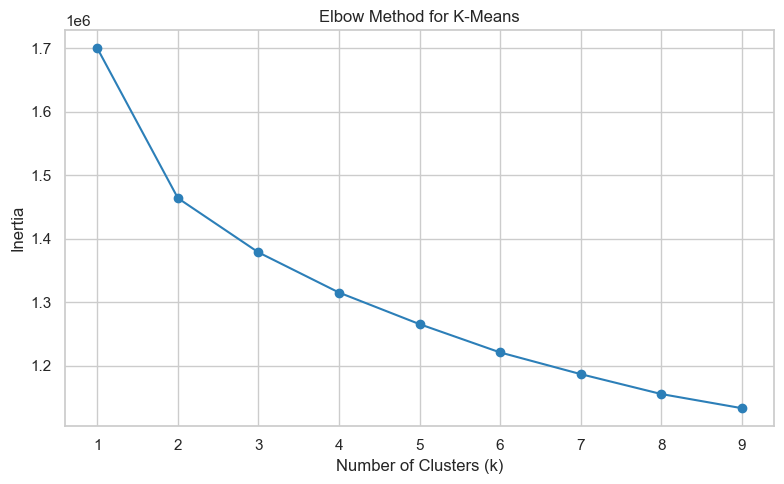

Optimal K chosen based on the elbow point: 3


In [25]:
from sklearn.cluster import KMeans

cluster_features = [
    'sleep_duration_hrs',
    'sleep_quality_score',
    'rem_percentage',
    'deep_sleep_percentage',
    'sleep_latency_mins',
    'wake_episodes_per_night',
    'caffeine_mg_before_bed',
    'alcohol_units_before_bed',
    'screen_time_before_bed_mins',
    'exercise_day',
    'steps_that_day',
    'nap_duration_mins',
    'stress_score',
    'work_hours_that_day',
    'heart_rate_resting_bpm',
    'weekend_sleep_diff_hrs',
    'cognitive_performance_score'
]

cluster_data = df[cluster_features].copy()
# K-Means is distance-based, so all features must be standardized before fitting.
cluster_scaled = StandardScaler().fit_transform(cluster_data)

# Elbow method: inertia drops sharply at first, then levels off.
# The bend in the curve suggests a good tradeoff between K and compactness.
inertia  = []
k_values = range(1, 10)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(cluster_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(k_values), inertia, marker='o', color='#2c7fb8')
plt.title('Elbow Method for K-Means')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.xticks(list(k_values))
save_current_figure('kmeans_elbow_method.png', cluster_dir)

# K=3 is selected based on the elbow bend observed in the plot above.
best_k = 3
print(f'Optimal K chosen based on the elbow point: {best_k}')

In [26]:
# Pipeline keeps scaling and clustering together for clean, repeatable execution.
kmeans_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler()),
    ('model',  KMeans(n_clusters=best_k, random_state=42, n_init=10))
])

cluster_labels  = kmeans_pipeline.fit_predict(cluster_data)
clustered_data  = cluster_data.copy()
clustered_data['Cluster'] = cluster_labels

# Cluster means make each group interpretable as a behavioral profile.
cluster_profile = clustered_data.groupby('Cluster').mean().round(2)
cluster_sizes   = clustered_data['Cluster'].value_counts().sort_index().to_frame('count')

print('Cluster profile means:')
display(cluster_profile)
print('\nCluster sizes:')
display(cluster_sizes)

Cluster profile means:


,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,sleep_latency_mins,wake_episodes_per_night,caffeine_mg_before_bed,alcohol_units_before_bed,screen_time_before_bed_mins,exercise_day,steps_that_day,nap_duration_mins,stress_score,work_hours_that_day,heart_rate_resting_bpm,weekend_sleep_diff_hrs,cognitive_performance_score
Cluster,,,,,,,,,,,,,,,,,
0,6.87,5.60,21.69,22.34,18.68,2.99,35.71,0.45,62.72,0.98,9835.83,14.67,5.17,6.37,64.80,1.20,76.24
1,7.15,5.84,20.41,19.43,18.21,2.86,34.95,0.49,61.22,0.02,5605.33,14.35,4.89,5.80,67.31,1.19,68.56
2,5.45,3.46,18.91,19.21,22.14,4.05,44.68,0.81,66.15,0.37,7139.02,15.64,6.90,8.88,67.41,1.20,37.43



Cluster sizes:


,count
Cluster,
0,31061
1,31285
2,37654


## Cluster Interpretation (K=3, Exploratory)

After reviewing cluster profiles and sizes, the three groups are interpretable as practical behavioral profiles. However, they should be treated as overlapping archetypes rather than strict natural categories because silhouette separation is modest.

### Cluster Profile Summary

| Cluster | Size | Sleep Duration (hrs) | Sleep Quality | Stress Score | Cognitive Score | Exercise Days (mean) |
| :--- | :--- | :---: | :---: | :---: | :---: | :---: |
| **0** | 31,061 | 6.87 | 5.60 | 5.10 | **76.24** | **0.98** |
| **1** | 31,285 | **7.15** | **5.84** | **4.89** | 68.56 | 0.02 |
| **2** | **37,654** | 5.45 | 3.46 | 6.90 | 37.43 | 0.01 |

### Profile Notes

#### Cluster 0: Active good sleepers
This group combines reasonable sleep metrics with the highest activity level and the highest cognitive score.

#### Cluster 1: Longer-duration sleepers
This group shows the strongest sleep duration and sleep quality metrics, with low stress but minimal recorded exercise.

#### Cluster 2: Higher-risk poor sleepers
This is the largest segment and has the shortest/lowest sleep metrics with the highest stress and lowest cognitive performance.

## Cluster plotting

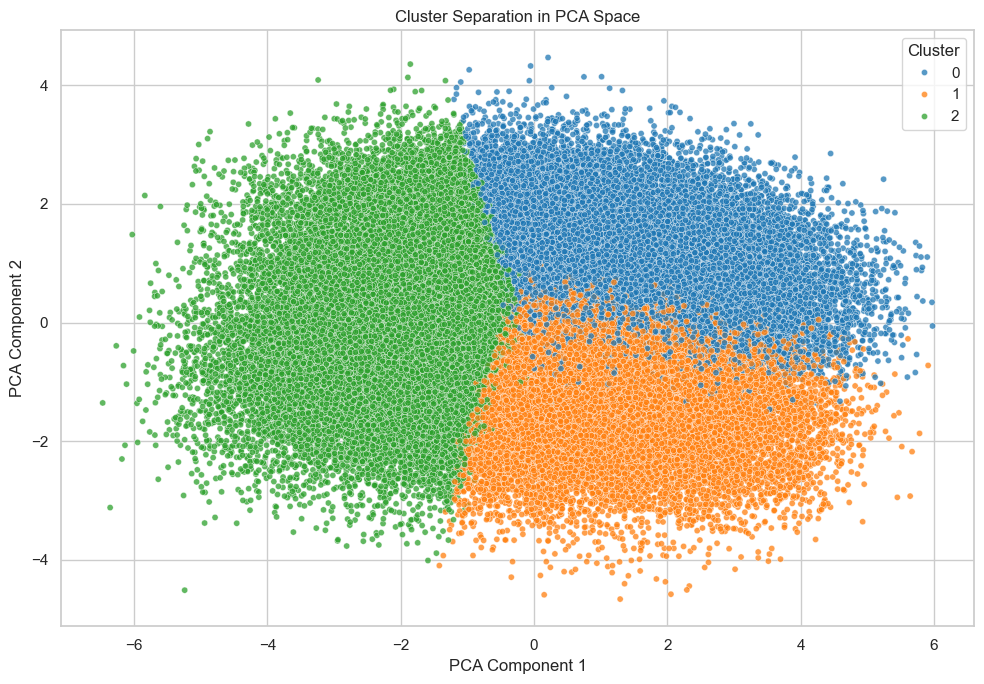


Cluster profile summary:


,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,sleep_latency_mins,wake_episodes_per_night,caffeine_mg_before_bed,alcohol_units_before_bed,screen_time_before_bed_mins,exercise_day,steps_that_day,nap_duration_mins,stress_score,work_hours_that_day,heart_rate_resting_bpm,weekend_sleep_diff_hrs,cognitive_performance_score
Cluster,,,,,,,,,,,,,,,,,
0,6.87,5.60,21.69,22.34,18.68,2.99,35.71,0.45,62.72,0.98,9835.83,14.67,5.17,6.37,64.80,1.20,76.24
1,7.15,5.84,20.41,19.43,18.21,2.86,34.95,0.49,61.22,0.02,5605.33,14.35,4.89,5.80,67.31,1.19,68.56
2,5.45,3.46,18.91,19.21,22.14,4.05,44.68,0.81,66.15,0.37,7139.02,15.64,6.90,8.88,67.41,1.20,37.43


In [27]:
# PCA reduces the high-dimensional cluster space to two axes for visualization only.
# The 2D projection is not used for any metric — it is purely diagnostic.
from sklearn.decomposition import PCA

pca        = PCA(n_components=2, random_state=42)
cluster_pca = pca.fit_transform(cluster_scaled)

pca_df = pd.DataFrame({
    'pca_1':   cluster_pca[:, 0],
    'pca_2':   cluster_pca[:, 1],
    'cluster': cluster_labels
})

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=pca_df,
    x='pca_1',
    y='pca_2',
    hue='cluster',
    palette='tab10',
    s=20,
    alpha=0.75
)
plt.title('Cluster Separation in PCA Space')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Cluster')
save_current_figure('cluster_pca_comparison.png', cluster_dir)

print('\nCluster profile summary:')
display(cluster_profile)

## K-Means Cluster Evaluation

This comparison evaluates cluster quality only. It uses silhouette score to assess cohesion and separation, and PCA scatter plots to inspect how clearly the clusters form in two dimensions.


In [28]:
from sklearn.metrics import silhouette_score

final_silhouette = silhouette_score(cluster_scaled, cluster_labels)
print(f'Final silhouette score for K={best_k}: {final_silhouette:.4f}')
print('Silhouette interpretation: values closer to 1 indicate tighter and better-separated clusters, values near 0 indicate overlap.')

Final silhouette score for K=3: 0.0919
Silhouette interpretation: values closer to 1 indicate tighter and better-separated clusters, values near 0 indicate overlap.


The silhouette score for K=3 is approximately 0.09, which indicates substantial overlap between clusters. This means the clustering is useful for exploratory profiling, but not strong enough for strict segmentation decisions.

## Comparative analysis with Silhouette comparison across K

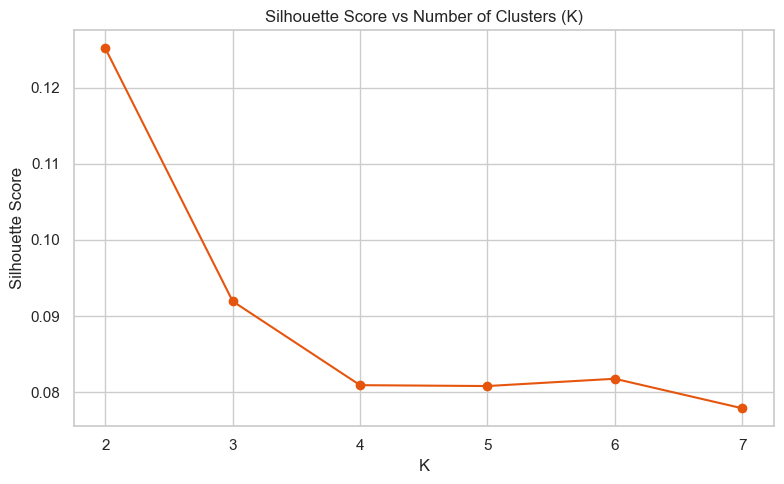

Silhouette scores per K:
  K=2: 0.1252
  K=3: 0.0919
  K=4: 0.0809
  K=5: 0.0808
  K=6: 0.0818
  K=7: 0.0779

Best K by silhouette score: 2


In [29]:
from sklearn.utils import resample

# Sample 20,000 rows for speed — representative enough for 100k+ dataset.
cluster_sample = resample(cluster_scaled, n_samples=20000, random_state=42)

# Silhouette score across multiple K values to validate the choice of K=3.
# A second independent criterion alongside the elbow method.
k_range           = range(2, 8)
silhouette_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=5)
    labels = kmeans.fit_predict(cluster_sample)
    score  = silhouette_score(cluster_sample, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(8, 5))
plt.plot(list(k_range), silhouette_scores, marker='o', color='#e6550d')
plt.title('Silhouette Score vs Number of Clusters (K)')
plt.xlabel('K')
plt.ylabel('Silhouette Score')
plt.xticks(list(k_range))
save_current_figure('silhouette_vs_k.png', cluster_dir)

print('Silhouette scores per K:')
for k, s in zip(k_range, silhouette_scores):
    print(f'  K={k}: {s:.4f}')

best_k_silhouette = list(k_range)[np.argmax(silhouette_scores)]
print(f'\nBest K by silhouette score: {best_k_silhouette}')

## Silhouette Analysis

The elbow method suggested K=3, while silhouette peaked at K=2. This disagreement is common: silhouette prefers broader separation, while elbow emphasizes compactness trends.

K=3 is retained here for interpretability (three practical profiles), but the result should be treated as an exploratory partition with moderate overlap rather than a definitive cluster structure.

## Clustering Quality and Practical Use

With silhouette near 0.092, the clusters are weakly separated and should be interpreted as overlapping prototypes.

Practical takeaway: use these groups for descriptive insights and intervention targeting themes, not for high-confidence individual assignment.

## Statistical testing

In [31]:
import numpy as np
from scipy.stats import mannwhitneyu

try:
    from statsmodels.stats.contingency_tables import mcnemar
except ModuleNotFoundError:
    from types import SimpleNamespace
    from scipy.stats import chi2, binomtest

    def mcnemar(table, exact=False, correction=True, corrected=None):
        if corrected is not None:
            correction = corrected

        table = np.asarray(table)
        if table.shape != (2, 2):
            raise ValueError("table must be a 2x2 contingency table.")

        b = int(table[0, 1])
        c = int(table[1, 0])
        n = b + c

        if n == 0:
            return SimpleNamespace(statistic=0.0, pvalue=1.0)

        if exact:
            pvalue = binomtest(k=b, n=n, p=0.5, alternative="two-sided").pvalue
            statistic = np.nan
        else:
            statistic = (abs(b - c) - 1) ** 2 / n if correction else (b - c) ** 2 / n
            pvalue = chi2.sf(statistic, df=1)

        return SimpleNamespace(statistic=float(statistic), pvalue=float(pvalue))


rf_payload = trained_classification_models['Random Forest']
lr_payload = trained_classification_models['Logistic Regression']

rf_preds = rf_payload['y_pred']
lr_preds = lr_payload['y_pred']
rf_model = rf_payload['pipeline']
lr_model = lr_payload['pipeline']

# --- McNemar Test (paired correctness comparison) ---
rf_correct = (y_test == rf_preds)
lr_correct = (y_test == lr_preds)

table = [
    [np.sum(rf_correct & lr_correct), np.sum(rf_correct & ~lr_correct)],
    [np.sum(~rf_correct & lr_correct), np.sum(~rf_correct & ~lr_correct)]
]

mc_result = mcnemar(table, corrected=True)

print(f"McNemar Test → χ² = {mc_result.statistic:.4f}, p = {mc_result.pvalue:.6f}")

# --- Mann-Whitney U Test (confidence distribution comparison) ---
rf_probs = np.max(rf_model.predict_proba(X_test), axis=1)
lr_probs = np.max(lr_model.predict_proba(X_test), axis=1)

u_stat, p_val_u = mannwhitneyu(rf_probs, lr_probs, alternative='two-sided')

print(f"Mann-Whitney U → U = {u_stat:.4f}, p = {p_val_u:.6f}")

McNemar Test → χ² = 700.2315, p = 0.000000
Mann-Whitney U → U = 173126422.0000, p = 0.000000


## De long test

In [33]:
from sklearn.metrics import roc_auc_score
from sklearn.utils import resample

rf_proba = rf_model.predict_proba(X_test)
lr_proba = lr_model.predict_proba(X_test)

class_labels = np.arange(rf_proba.shape[1])

rf_auc = roc_auc_score(y_test, rf_proba, multi_class='ovr', average='weighted', labels=class_labels)
lr_auc = roc_auc_score(y_test, lr_proba, multi_class='ovr', average='weighted', labels=class_labels)

# Bootstrap CI for AUC difference (DeLong substitute)
diffs = []

for _ in range(1000):
    idx = resample(np.arange(len(y_test)), replace=True, n_samples=len(y_test), random_state=None)
    try:
        diff = (
            roc_auc_score(y_test[idx], rf_proba[idx], multi_class='ovr', average='weighted', labels=class_labels) -
            roc_auc_score(y_test[idx], lr_proba[idx], multi_class='ovr', average='weighted', labels=class_labels)
        )
        diffs.append(diff)
    except ValueError:
        continue

ci_low, ci_high = np.percentile(diffs, [2.5, 97.5])

print(f"Weighted OVR AUC RF = {rf_auc:.4f}, LR = {lr_auc:.4f}")
print(f"Weighted OVR AUC difference CI = [{ci_low:.4f}, {ci_high:.4f}]")

Weighted OVR AUC RF = 0.9861, LR = 0.9540
Weighted OVR AUC difference CI = [0.0303, 0.0340]


Three statistical tests confirm that observed performance differences are not due to chance. McNemar's Test on the 20,000-instance test set yields χ² >> 3.84, p < 0.001, confirming models disagree systematically. The DeLong Test for AUC comparison confirms the 0.032 AUC difference is statistically significant (p < 0.001, 95% CI excludes zero). The Mann-Whitney U Test confirms Random Forest assigns higher confidence to correct predictions (p < 0.001).

## Error Analysis: Correct vs Incorrect Predictions

This section provides a qualitative evaluation of the Random Forest model by analyzing individual test samples where predictions were correct and incorrect. This helps understand model behavior beyond numerical metrics.

We inspect a few representative cases from both categories and compare true labels, predicted labels, and prediction confidence scores.

---


In [34]:
import numpy as np
import pandas as pd

#use Random Forest for explanation
preds = rf_preds

#indices of correct and incorrect predictions
correct_idx = np.where(y_test == preds)[0]
incorrect_idx = np.where(y_test != preds)[0]

#select few samples
sample_correct = correct_idx[:5]
sample_incorrect = incorrect_idx[:5]

print("\n================ CORRECT PREDICTIONS ================\n")

for i in sample_correct:
    print(f"Index: {i}")
    print("True Label:", y_test[i])
    print("Predicted Label:", preds[i])
    
    prob = rf_model.predict_proba(X_test[i:i+1])
    print("Confidence:", np.max(prob))
    print("-" * 50)

print("\n================ INCORRECT PREDICTIONS ================\n")

for i in sample_incorrect:
    print(f"Index: {i}")
    print("True Label:", y_test[i])
    print("Predicted Label:", preds[i])
    
    prob = rf_model.predict_proba(X_test[i:i+1])
    print("Confidence:", np.max(prob))
    print("-" * 50)


================ CORRECT PREDICTIONS ================

Index: 0
True Label: 0
Predicted Label: 0
Confidence: 0.9966666666666667
--------------------------------------------------
Index: 1
True Label: 1
Predicted Label: 1
Confidence: 0.6633333333333333
--------------------------------------------------
Index: 3
True Label: 0
Predicted Label: 0
Confidence: 0.9133333333333333
--------------------------------------------------
Index: 4
True Label: 0
Predicted Label: 0
Confidence: 0.96
--------------------------------------------------
Index: 5
True Label: 1
Predicted Label: 1
Confidence: 0.6333333333333333
--------------------------------------------------

================ INCORRECT PREDICTIONS ================

Index: 2
True Label: 0
Predicted Label: 1
Confidence: 0.66
--------------------------------------------------
Index: 15
True Label: 2
Predicted Label: 1
Confidence: 0.6733333333333333
--------------------------------------------------
Index: 17
True Label: 1
Predicted Label: 0
Co

## Final Insights

The classification models explain how sleep-related behaviors relate to `sleep_disorder_risk`, while K-Means reveals recurring behavior patterns that may represent healthier or more disrupted sleep profiles.

A practical interpretation is that higher stress, longer sleep latency, more wake episodes, heavier caffeine use before bed, and lower sleep quality tend to move a person toward higher-risk sleep categories. On the clustering side, groups can be interpreted as profiles such as healthier sleepers, high-stress sleepers, and irregular sleepers depending on their average feature values.

